# Analyzing 2024 U.S. Presidential Voting Patterns
#### Spring 2026 Data Science Project
#### By: James Hawkins, Jason Yu, Enyu Liang, Akhil Shashtry

Contributions:

James:
- Project/Dataset Idea
- Exploratory Data Analysis Conclusion 1
- Machine Learning Analysis and Interpretations/Recommendations
- Data Curation for EDA and ML Analysis

Jason:

Enyu:

Akhil:

**Introduction:** The purpose of this analysis is to recognize and identify several key factors that were present in the 2024 U.S. Presidential Election in influencing the vote through the ANES Pre and Post-Election surveys. When examining such a dynamic and volatile environment, it is important to remain as holistic and impartial as possible in order to obtain a more comphrensive result and predictor. There is no singular value that can be used to predict a citizen's candidate choice, thus it is important for this tutorial to view several patterns and combine various factors' analysis together.

The primary question this tutorial seeks to answer is which factors are prevalent and important in determining the sociopolitical trends in the United States at a national level. Throughout this tutorial, we will aim to examine the information presented in the ANES survey and uncover as many predictors for voting patterns as possible. Understanding which values and attributes are important to the American people can be key in assessing how the political landscape of the U.S. is changing in contemporary times from a data-driven standpoint.



**Data Curation:**

**Exploratory Data Analysis:** 

Now, we will use a machine learning method in order to do some analysis and try to uncover patterns in the ANES dataset.

Based on our exploratory data analysis, we will choose the following features in order to try and predict a voter's preferred candidate: race, household income, age group, and importance of American identity.

We will begin by compiling an appropriate dataset to pass into an ML model.

In [15]:
# Import libraries
import pandas as pd

# Loading in the dataset

anes2024_csv = "../../dataset/data_2024/anes_timeseries_2024_csv_20250808.csv"
df2024 = pd.read_csv(anes2024_csv)

df2024_select = df2024[["V241501x", "V241567x", "V241566x", "V241039", "V240108a",
                        "V240002c", "V242067", # Race, Income, Presidential Choice
                        "V241458x", # Age
                        "V242066", # Voted?
                        "V242536" # American Identity
                        ]]
df2024_select

/var/folders/g2/vvdf2tl51t998r9wwxwrcdym0000gn/T/ipykernel_99517/248988302.py:7: DtypeWarning: Columns (0: V240101a, 1: V240101c, 2: V240101d, 3: V240103a, 4: V240103c, 5: V240103d, 6: V240104a, 7: V240104c, 8: V240104d, 9: V240105a, 10: V240105c, 11: V240105d, 12: V240106a, 13: V240106c, 14: V240106d, 15: V240108a, 16: V240108c, 17: V240108d, 18: V243002, 19: V243003, 20: V243004, 21: V243005, 22: V243006, 23: V243009, 24: V243050, 25: V243051, 26: V243052, 27: V243053, 28: V243056, 29: V243057, 30: V243058) have mixed types. Specify dtype option on import or set low_memory=False.
  df2024 = pd.read_csv(anes2024_csv)


,V241501x,V241567x,V241566x,V241039,V240108a,V240002c,V242067,V241458x,V242066,V242536
0,3,5,27,-1,0.809064,2,2,50,1,1
1,4,5,26,-1,2.575472,2,-1,41,-1,3
2,1,5,24,-1,0.798864,2,1,44,1,5
3,4,3,12,-1,0.244757,2,-1,45,-1,2
4,1,3,15,-1,0.239209,2,2,80,1,4
...,...,...,...,...,...,...,...,...,...,...
5516,-8,2,5,-1,0.19183,1,-6,-2,-6,-6
5517,1,3,16,-1,2.869063,2,1,69,1,3
5518,2,3,12,-9,2.092296,1,-6,-2,-6,-6
5519,2,4,19,-1,2.826738,2,1,28,1,3


In [16]:
# Dictionaries for conversion: we convert the ANES encoded values into readable strings.

race_dict = { # V241501x
    -9: "Refused",
    -8: "Don’t Know",
    -4: "Error",
    1: "White", #"White, non-Hispanic",
    2: "Black", #"Black, non-Hispanic",
    3: "Hispanic",
    4: "Asian/Pacific-Islander", #"Asian or Native Hawaiian/other Pacific Islander, non-Hispanic",
    5: "Native American/Other", #"Native American/Alaska Native or other race, non-Hispanic",
    6: "Multiple Races", #"Multiple races, non-Hispanic",
}

household_income_6_cat_dict = { # V241567x
    -9: "Refused",
    -5: "Break off, sufficient partial",
    -4: "Error",
    1: "<$10k", #"Under $9,999",
    2: "$10k-30k", #"$10,000 to $29,999",
    3: "$30k-60k", #"$30,000 to $59,999",
    4: "$60k-100k", #"$60,000 to $99,999",
    5: "$100k-250k", #"$100,000 to $249,999",
    6: "$250k+", #"$250,000 or more",
}

president_dict = { # V242067
    -9: "Refused",
    -1: "Inapplicable",
    1: "Harris", #"Kamala Harris",
    2: "Trump", #"Donald Trump",
    3: "RFK Jr.", #"Robert F. Kennedy, Jr.",
    4: "West", #"Cornel West",
    5: "Stein", #"Jill Stein",
    6: "Other", #"Another candidate {SPECIFY}"
}

complete_survey_dict = {
    1: 0,
    2: 1
}

#V242066 - Did R vote for President
voted_dict = {
    -7: "Insufficient Partial",
    -6: "No Post Interview",
    -1: "Inapplicable",
    1: "Yes",
    2: "No"
}

def age_group(age):
    if age < 18:
        return "Under 18"
    elif age >= 18 and age < 45:
        return "18-44"
    elif age >= 45 and age < 65:
        return "45-64"
    elif age >= 65:
        return "65 and over"
    else:
        return "Missing"
    
nationalism_dict = { # V242536
    -9: "Refused",
    -7: "Insufficient partial, interview deleted",
    -6: "No post interview",
    -5: "Sufficient partial, breakoff",
    -1: "Inapplicable",
    1: "Extremely important",
    2: "Very important",
    3: "Moderately important",
    4: "A little important",
    5: "Not at all important"
}

In [17]:
# Making the dataset more readable by applying the previous dictionaries and functions.
df2024_select["Race"] = df2024_select["V241501x"].map(race_dict)
df2024_select["Household Income"] = df2024_select["V241567x"].map(household_income_6_cat_dict)
df2024_select["President Vote"] = df2024_select["V242067"].map(president_dict)
df2024_select["Completed Survey"] = df2024_select["V240002c"].map(complete_survey_dict)
df2024_select["Voted"] = df2024_select["V242066"].map(voted_dict)
df2024_select["Age Group"] = df2024_select["V241458x"].apply(age_group)
df2024_select["American Identity"] = df2024_select["V242536"].map(nationalism_dict)

# Clean up 'Weights': replace empty strings with 0.
df2024_select["Weights"] = df2024_select["V240108a"]
df2024_select["Weights"] = df2024_select["Weights"].apply(lambda x: 0 if x == ' ' or x == '' else x)
df2024_select["Weights"] = df2024_select["Weights"].astype(float)

# Select these re-labelled columns of interest.
df2024_clean = df2024_select[["Race", "Household Income", "Age Group", "American Identity",
                              "President Vote", "Completed Survey", "Weights"]]

df2024_clean

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5516,Don’t Know,$10k-30k,Under 18,No post interview,NaN,0,0.191830
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5518,Black,$30k-60k,Under 18,No post interview,NaN,0,2.092296
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [18]:
# We will remove all missing values, order the orginal variables, and keep only people who 
# completed the survey (i.e. answered after the election).

# Dealing with missing values
df2024_clean.dropna()
df2024_clean

# Order variables
incomes = ["<$10k", "$10k-30k", "$30k-60k", "$60k-100k", "$100k-250k", "$250k+",
           "Refused", "Break off, sufficient partial", "Error"]
df2024_clean["Household Income"] = pd.Categorical(values = df2024_clean["Household Income"],
                                                  categories = incomes, ordered = True)
nationalism = ["Not at all important", "A little important", "Moderately important",
               "Very important", "Extremely important", "Refused", "Inapplicable",
               "No post interview", "Insufficient partial, interview deleted",
               "Sufficient partial, breakoff"]
df2024_clean["American Identity"] = pd.Categorical(values = df2024_clean["American Identity"],
                                                  categories = nationalism, ordered = True)

# Only keep people who completed the survey.
df2024_relevant = df2024_clean[df2024_clean["Completed Survey"] == 1]

df2024_relevant

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
1,Asian/Pacific-Islander,$100k-250k,18-44,Moderately important,Inapplicable,1,2.575472
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
3,Asian/Pacific-Islander,$30k-60k,45-64,Very important,Inapplicable,1,0.244757
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
...,...,...,...,...,...,...,...
5514,White,$100k-250k,18-44,Very important,Inapplicable,1,0.797417
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [19]:
# Simplifying Data: we will remove every person who gave an ambiguous category, for any variable.

df2024_simplified = df2024_relevant[df2024_relevant["Race"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Race"] != "Inapplicable"]

# Turn third-party candidates into one category.
def collapse_third_party(vote):
    if vote in ["West", "Stein", "Other"]:
        return "Other"
    else:
        return vote

df2024_simplified["President Vote"] = df2024_simplified["President Vote"].apply(collapse_third_party)

# Filter to people who answered about who the voted for.
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["President Vote"] != "Inapplicable"]

# Filter to people who answered about their income
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Error"]
df2024_simplified = df2024_simplified[df2024_simplified["Household Income"] != "Break off, sufficient partial"]

# Filter to people who answered about their age
df2024_simplified = df2024_simplified[df2024_simplified["Age Group"] != "Missing"]

# Filter to people who answered about American Identity
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Refused"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Inapplicable"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "No post interview"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Insufficient partial, interview deleted"]
df2024_simplified = df2024_simplified[df2024_simplified["American Identity"] != "Sufficient partial, breakoff"]


df2024_simplified = df2024_simplified[df2024_simplified["President Vote"].isna() != True]


df2024_simplified

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042
...,...,...,...,...,...,...,...
5507,White,$60k-100k,45-64,Moderately important,Other,1,3.652063
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738


In [20]:
# "Other" category for president choice may not be as important, because it is so sparse. 
# So how about we trim the dataset down to just predicting Trump/Harris, 
# and we'll use a binary encoding.

# Make the output binary.
df2024_binary = df2024_simplified[df2024_simplified["President Vote"] != "Other"]

df2024_binary["President Vote Binary"] = df2024_binary["President Vote"].apply(lambda vote:  1 if vote == "Harris" else 0)
df2024_binary

,Race,Household Income,Age Group,American Identity,President Vote,Completed Survey,Weights,President Vote Binary
0,Hispanic,$100k-250k,45-64,Extremely important,Trump,1,0.809064,0
2,White,$100k-250k,18-44,Not at all important,Harris,1,0.798864,1
4,White,$30k-60k,65 and over,A little important,Trump,1,0.239209,0
6,White,$30k-60k,18-44,Moderately important,Trump,1,0.290135,0
10,White,$100k-250k,45-64,Moderately important,Harris,1,0.940042,1
...,...,...,...,...,...,...,...,...
5506,White,$60k-100k,45-64,Extremely important,Harris,1,0.256140,1
5515,Hispanic,<$10k,65 and over,Extremely important,Harris,1,0.129755,1
5517,White,$30k-60k,65 and over,Moderately important,Harris,1,2.869063,1
5519,Black,$60k-100k,18-44,Moderately important,Harris,1,2.826738,1


We have our feature-transformed dataset ready to be fed into an ML model. Our output (voter choice) is categorical, so we will use a classification method. And because all of our features are categorical, and voters are split among many different combinations of category values, it would be most apt to try
and predict Presidential vote choice using a Decision Tree: a machine learning model that splits a dataset into successive subsets based on the most significant feature at each step, and then assigns a prediction to each of the final set of subsets.

We will specifically use the [CatBoostClassifier](https://catboost.ai/docs/en/concepts/python-reference_catboostclassifier) from the [CatBoost library](https://catboost.ai/) as our model, because (unlike a Scikit-Learn [DecisionTreeClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)), it is able to process raw categorical/string values, which our data consists of.

In [21]:
# Import the libraries.
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'catboost'

In [ ]:
# Catboost Decision Tree with binary output
seed = 42 # For determinism, because the model has a degree of randomness.

# Extract the relevant columns for the model. X is the inputted features used to predict y,
# the target. w is the weights of each row.
X = df2024_binary[["Race", "Household Income", "Age Group", "American Identity"]]
y = df2024_binary["President Vote"]
w = df2024_binary["Weights"]

# Split data into training sets and test sets. 80% will train the model, 20% will be used
# to test/evaluate it.
test_size = 0.2
Xtrain, Xtest, ytrain, ytest, wtrain, wtest = train_test_split(X, y, w, test_size=test_size,
                                                               random_state=seed, stratify=y)
# The last parameter, stratify = y, means that the data will be split so that the proportions of
# "Trump" and "Harris" voters is the same in the train and test datasets as in the overall dataset.

In [ ]:
# Training the Decision Tree
categories = X.columns.tolist()
# Initialize the model
cat_dtree_bin = CatBoostClassifier(random_state=seed, cat_features=categories, verbose = 0)
# Fit it on the training data.
cat_dtree_bin.fit(Xtrain, ytrain, sample_weight=wtrain)

CatBoostClassifier(cat_features=['Race', 'Household Income', 'Age Group', 'American Identity'], random_state=42, verbose=0)

Text(0.5, 1.0, 'Test Accuracy: 0.7132883897772595')

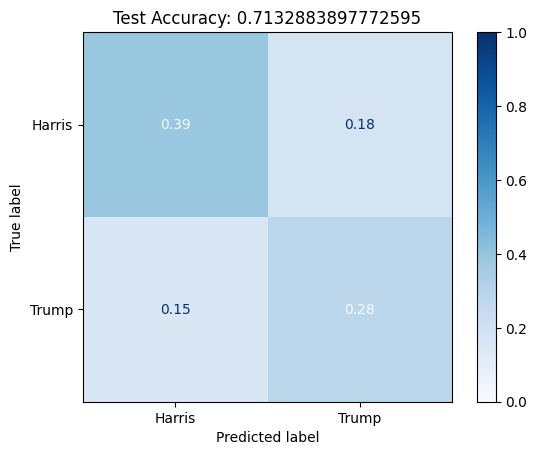

In [40]:
# Evaluation on test data: we use the model to predict the Presidential Candidate
# given the features of the test data.
y_pred = cat_dtree_bin.predict(Xtest)

# Predict the accuracy score: how many predictions were correct.
accuracy = accuracy_score(ytest, y_pred, sample_weight=wtest)

# Print the confusion matrix.
con_mat = confusion_matrix(ytest, y_pred)
con_mat = con_mat / con_mat.sum()
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)
plot.im_.set_clim(vmin = 0, vmax = 1)
plt.title(f"Test Accuracy: {accuracy}")

Interpretation:

This **confusion matrix** displays the proportions of correct and incorrect predictions among the test data. We can see that 39% of the model's predictions were correct predictions for Harris, 28% were correct predictions for Trump, 18% were incorrect predictions for Trump, and 15% were incorrect predictions for Harris.

The overall accuracy is about 71.3%, which is about as ideal as one can get from a dataset such as the ANES. The ANES represents real-world, social data, which is often extremely noisy and has many features. We narrowed this dataset down to four prediction features, so this model turns out to be pretty good at predicting Presidential Candidate preference with its >70% accuracy.

We'll also show the confusion matrix for the training data: it is similar to that of the testing data, so we can be confident that the model has neither underfit nor overfit on the data. It has about discovered the patterns in the data between our four selected prediction features (race, household income, age group, and American identity importance) and the target feature (Presidential vote choice).

Text(0.5, 1.0, 'Train Accuracy: 0.728780983753099')

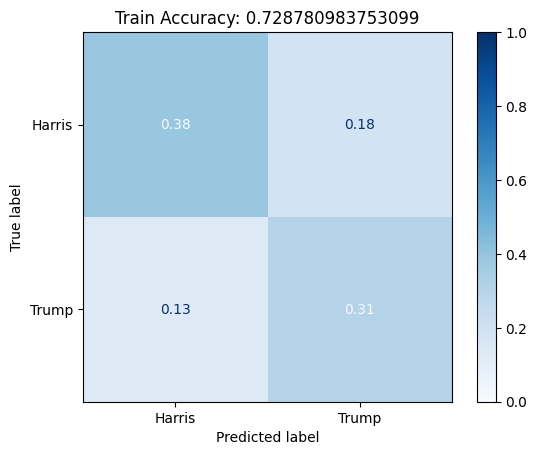

In [42]:
# Evaluation on train data.
y_pred_train = cat_dtree_bin.predict(Xtrain)

accuracy = accuracy_score(ytrain, y_pred_train, sample_weight=wtrain)

con_mat = confusion_matrix(ytrain, y_pred_train)
con_mat = con_mat / con_mat.sum()
labels = cat_dtree_bin.classes_
plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
plot.plot(cmap = plt.cm.Blues)
plot.im_.set_clim(vmin = 0, vmax = 1)
plt.title(f"Train Accuracy: {accuracy}")

We will now, in order to help our policy reccomendations, look at the model's predictions for each category of the prediction features. In order to do that, we will first format the data so we can compute the confusion matrices of each category efficiently.

We'll look just at the test data:

In [15]:
# We will go and display the confusion matrices per each result.
dfresults = Xtest.copy()
dfresults["Prediction"] = y_pred
dfresults["Actual"] = ytest
dfresults["Weight"] = wtest
dfresults

,Race,Household Income,Age Group,American Identity,Prediction,Actual,Weight
666,Hispanic,$100k-250k,18-44,Extremely important,Harris,Harris,1.479550
2738,White,$60k-100k,45-64,Very important,Trump,Trump,0.175571
2421,White,$100k-250k,45-64,Extremely important,Trump,Trump,0.640016
1111,White,$60k-100k,45-64,Very important,Trump,Harris,0.829128
4038,Multiple Races,$100k-250k,18-44,Very important,Harris,Trump,1.874986
...,...,...,...,...,...,...,...
4298,Hispanic,$30k-60k,18-44,Moderately important,Harris,Trump,0.722789
2346,White,$250k+,65 and over,Moderately important,Harris,Harris,3.250217
3685,White,$60k-100k,45-64,Moderately important,Harris,Harris,0.388935
1136,Asian/Pacific-Islander,$100k-250k,18-44,Extremely important,Trump,Trump,0.660018


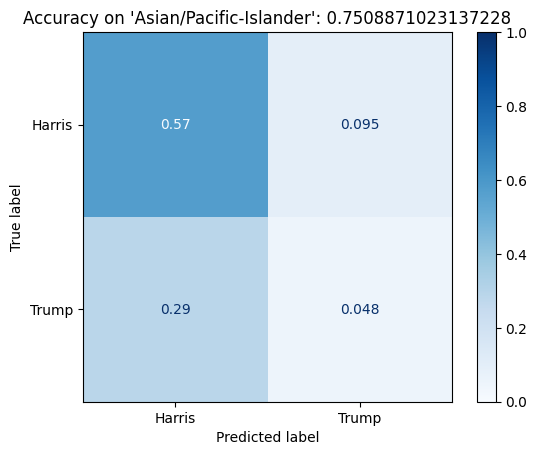

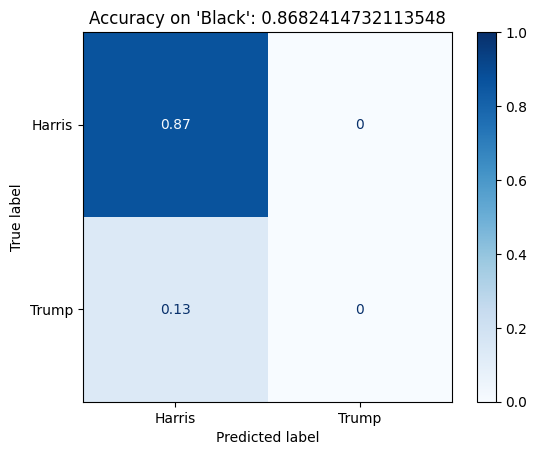

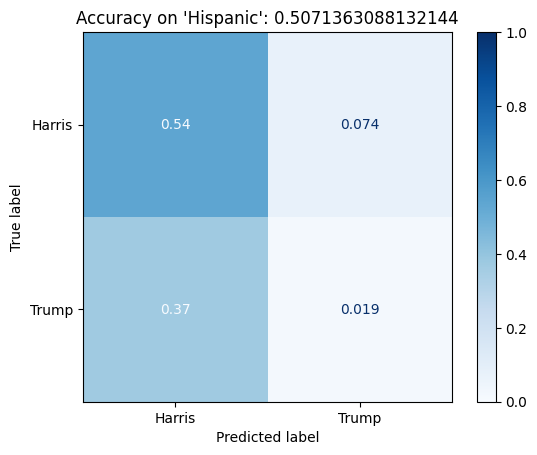

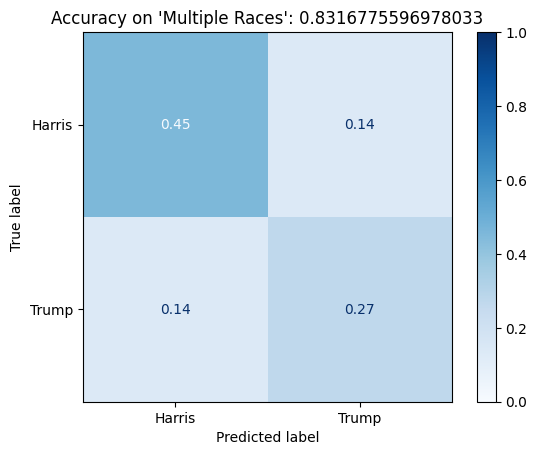

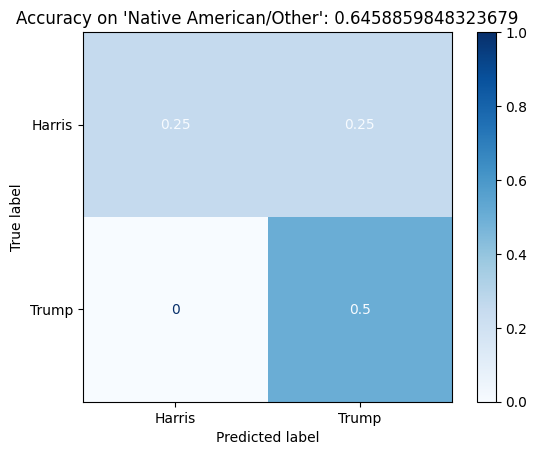

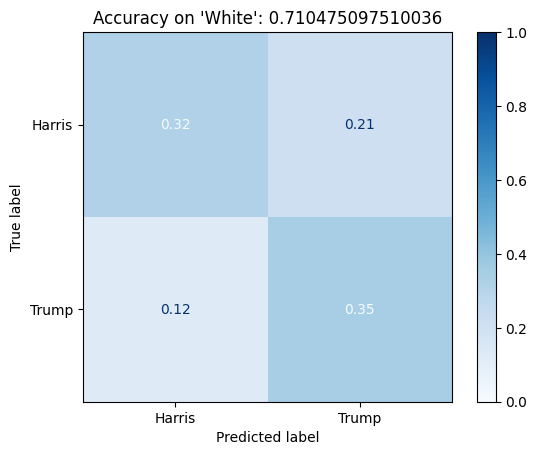

In [27]:
# Race Confusion Matrices
for race, race_df in dfresults.groupby("Race"):
    accuracy = accuracy_score(race_df["Actual"], race_df["Prediction"],
                              sample_weight=race_df["Weight"])
    title = f"Accuracy on '{race}': {accuracy}"

    con_mat = confusion_matrix(race_df["Actual"], race_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices for each racial group, the model does really well on predicting the votes of African-Americans (mostly for Harris) and people of multiple races (about evenly split between both candidates). It performs moderately well on Whites (about evenly split) and Asian/Pacific Islanders (about 2/3 for Harris and 1/3 for Trump, but giving most to Harris). It perform less well on Native Americans (evenly split, but giving all to Trump), and poorly on Hispanics (split between Harris and Trump, but giving most to Harris).

It would be seen that being African-American is a great predictor of votes for Harris regardless of all other values, which would suggest that the Democrats should work to maintain their appeal to this group of voters.

The race of Whites and people of multiple races do not seem to have their votes well predicted by their race, according to this model, so it seems neither party should focus on these racial groups in their campaigning.

Asians and Hispanics tend to be predicted as voting for Harris, when in actuality both racial groups actually have a larger split between both candidates (likely due to other features under consideration). Since minority groups tend to support the Democrats, the Democrats should try to analyze what is pulling these groups away from them, and the Republicans would likely be benefitted from trying to appeal to these racial groups more.

Native Americans are a small group, so the results presented by this model about this survey may not be generalizable.

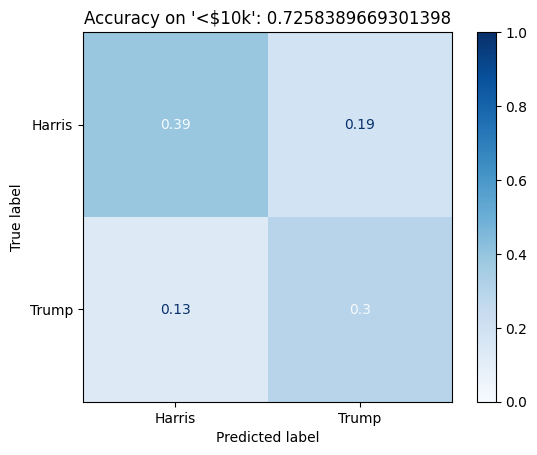

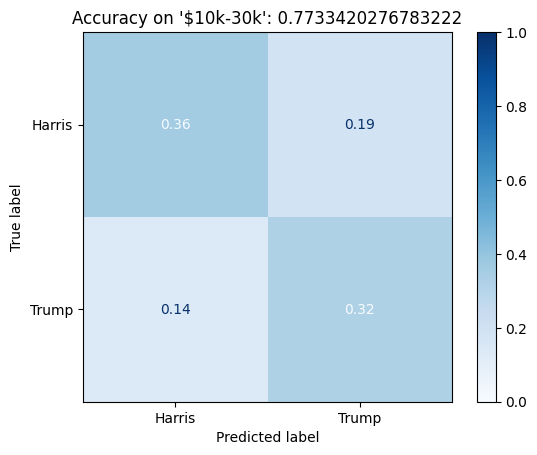

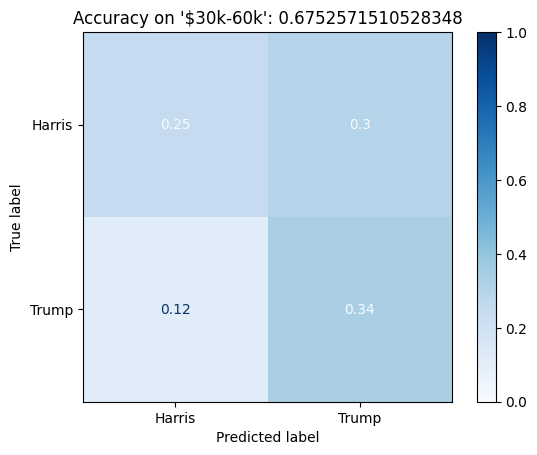

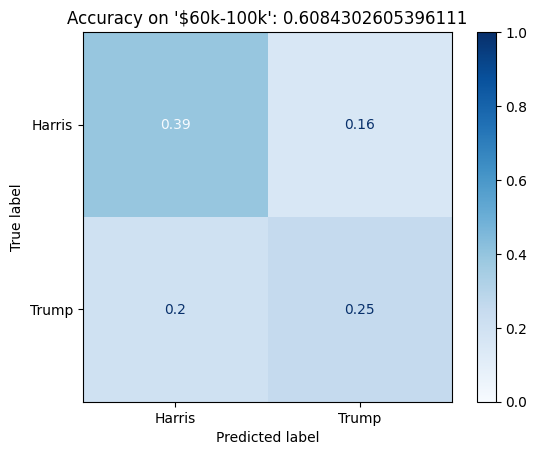

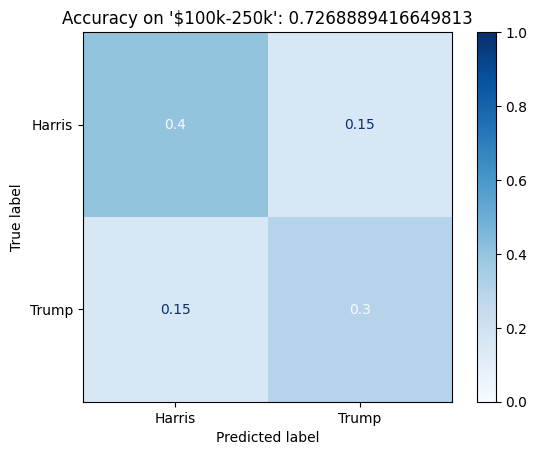

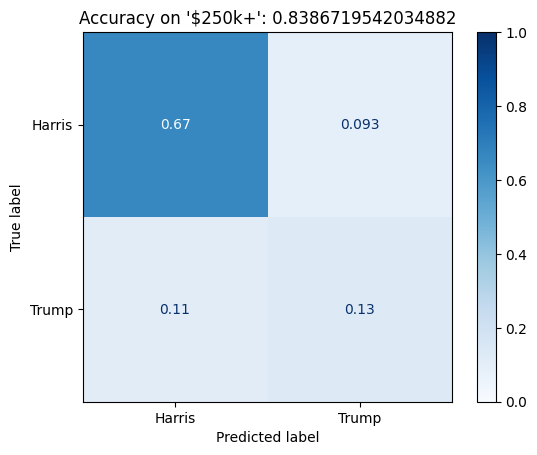

In [28]:
# Income Confusion Matrices
for income, income_df in dfresults.groupby("Household Income"):
    accuracy = accuracy_score(income_df["Actual"], income_df["Prediction"],
                              sample_weight=income_df["Weight"])
    title = f"Accuracy on '{income}': {accuracy}"

    con_mat = confusion_matrix(income_df["Actual"], income_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices by household income, we see that the model is only good at predicting the candidate choices of people with annual incomes higher than $250k, with more than 83.9% accuracy. A strong majority of these votes also go to Kamala Harris, which would suggest that the Democrats have a broad appeal to people with high-incomes, which they should keep in mind in their campaigning.

All of the other confusion matrices show the model with moderate to high-moderate accuracy (60-77%) for all of the other income groups, and it can be seen that the model's predictions for candidate choice are about evenly split (20-40% splits in accurate predictions). This would suggest that income--for all but the highest group--are not a good predictor of Presidential candidate choice, and so both parties should not try to appeal to any group of people based merely on their income. It would seem that other factors are confounding their choices.

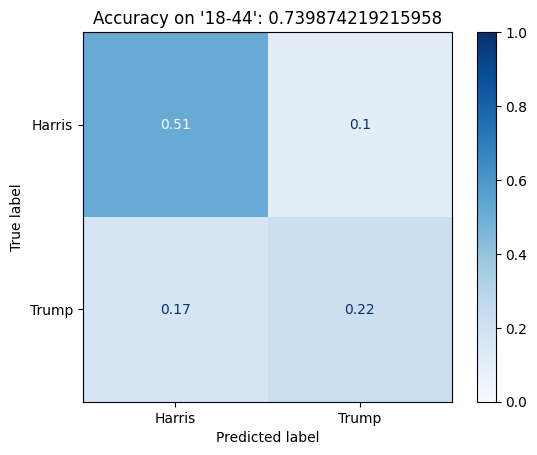

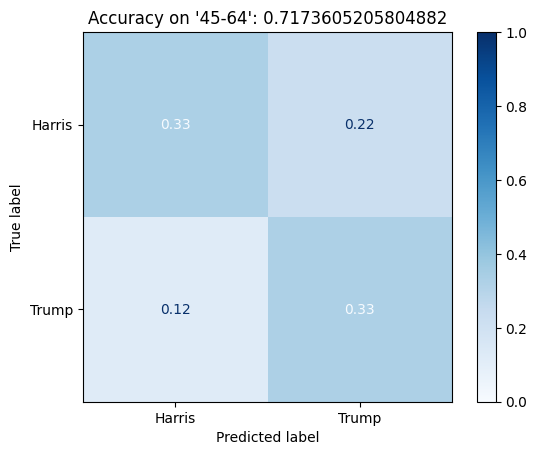

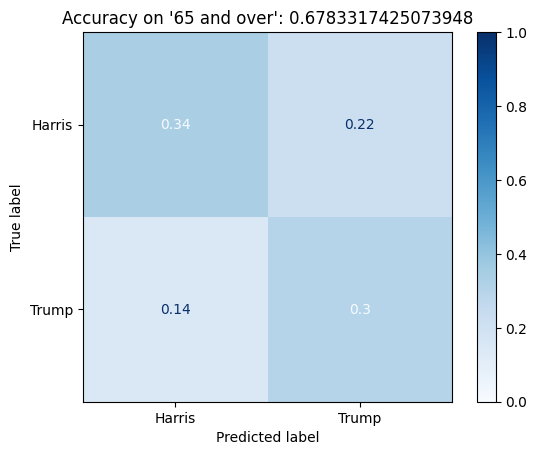

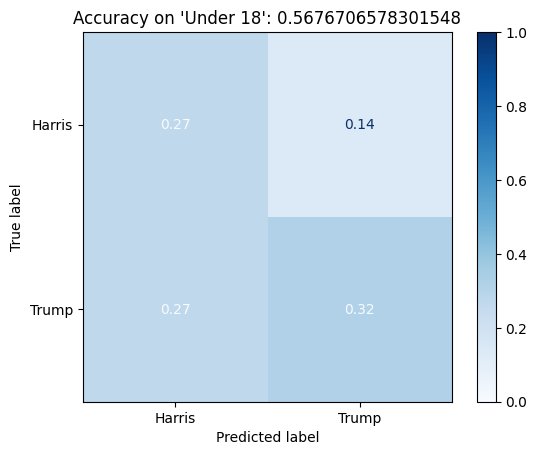

In [29]:
# Age Confusion Matrices
for age, age_df in dfresults.groupby("Age Group"):
    accuracy = accuracy_score(age_df["Actual"], age_df["Prediction"],
                              sample_weight=age_df["Weight"])
    title = f"Accuracy on '{age}': {accuracy}"

    con_mat = confusion_matrix(age_df["Actual"], age_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices of each age group, the model predicts candidate choice moderately well on all but the under 18 category, which would suggest that the vote choices of people under the age of eighteen years is not very predictable, given other factors. That should be kept in mind, so upcoming voters are not all that important to either party.

For the oldest two age groups, the correct predictions are about evenly split between Harris and Trump, which would suggest that people who are in the latter half of their life are just as likely to vote for either candidate, given their age. But for the group aged 18 to 44, a majority of the correct predictions are for Harris (51%), though a substantial proportion (22%) is for Trump. It would appear that it is easier to predict the vote choice of people who are younger and working-aged, and that they are more likely to choose the Democrats. The Democrats, in their campaigning, should then exploit their appeal to this group, while the Republicans should try and create an appeal to this group.

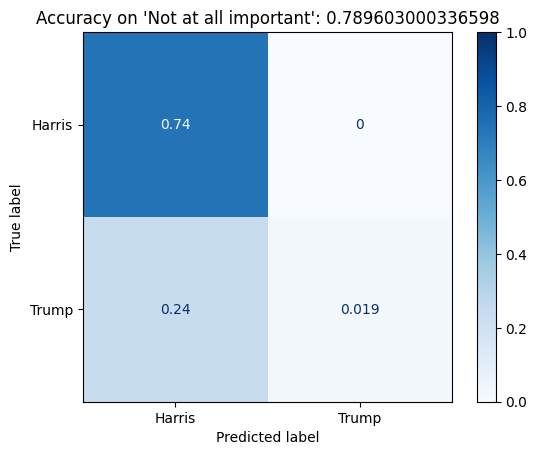

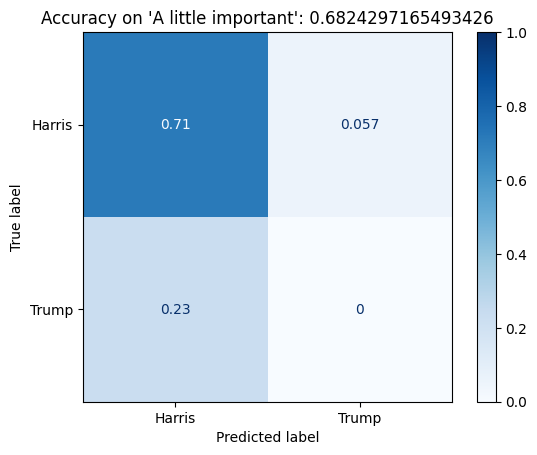

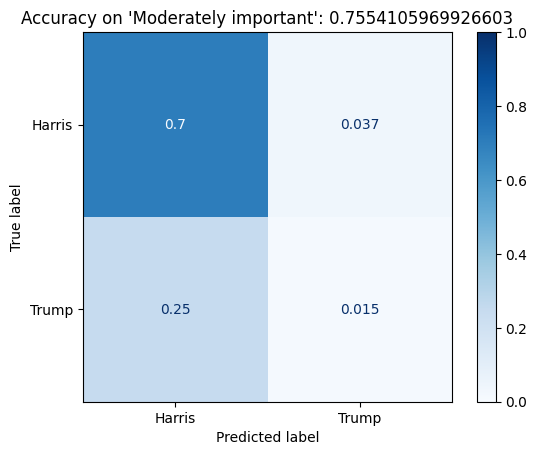

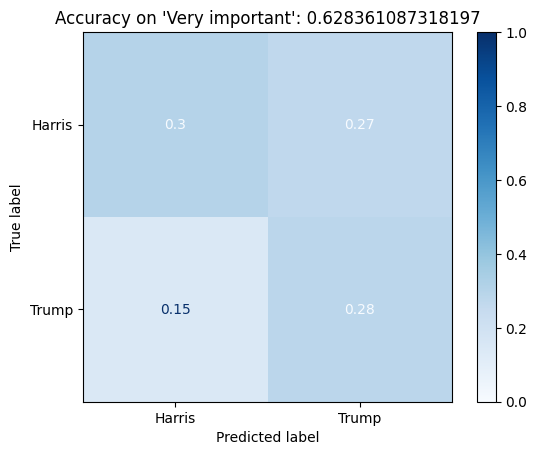

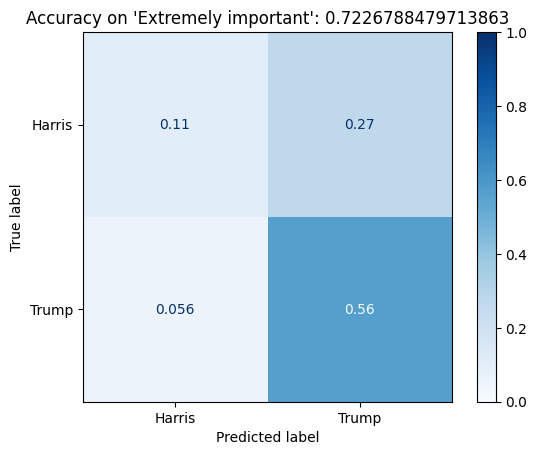

In [30]:
# Nationalism Confusion Matrices
for nation, nation_df in dfresults.groupby("American Identity"):
    accuracy = accuracy_score(nation_df["Actual"], nation_df["Prediction"],
                              sample_weight=nation_df["Weight"])
    title = f"Accuracy on '{nation}': {accuracy}"

    con_mat = confusion_matrix(nation_df["Actual"], nation_df["Prediction"])
    con_mat = con_mat / con_mat.sum()
    labels = cat_dtree_bin.classes_
    plot = ConfusionMatrixDisplay(confusion_matrix=con_mat, display_labels=labels)
    plot.plot(cmap = plt.cm.Blues)
    plot.im_.set_clim(vmin = 0, vmax = 1)
    plt.title(title)

Looking at the confusion matrices for the "American Identity" groups, the model performs fairly well at predicting the votes of people to whom being an American is "not at all important" and "moderately important", less well of people to whom it is "extremely important" and "a little important", and lower-moderately well for people to whom it is "very important".

It would appear for people who consider being an American "very important", they are about split between both candidates, and so it is not a good predictor of candidate choice. For every group lower than "very important", the model has more than 70% of the predictions being correct predictions for Harris. Meanwhile, for the group that considers being American "extremely important", 56% of the predictions are correct for Trump, and it predicts the strong majority of nationalist Americans to prefer Trump.

It would appear, based on these results, that for those to whom being an American is not so important, they are more much more likely to vote for Harris. In which case, the Democrats probably should not include too much nationalistic rhetoric in their campaigning in order to maintain touch with this voter base. Trump seems to have more strength in nationalistic circles, though, and so the Republicans can try and appeal to the people to whom being American is "very important" and try to draw them into the category that thinks it is "extremely important", which finds appeal in Republican candidates.

In summation, it would appear that:

The Democrats have stronger predictable appeal with
- African-Americans
- People of really high incomes
- People who are not so patriotic.

The Republicans have stronger predictable appeal with
- Nationalists

Traits that do not appear strongly favored to either candidate are:
- Whites, Asians, Hispanics, Mix-Raced
- Everyone below the upper class
- Middle-aged and elderly

The two parties can adjust their campaign strategies according to the likely responses of these groups: consolidate appeals among the ones likely to choose them, and try to reach out to the ones that don't have strong observed preference yet.